# Exemplo Prático: Neurônios de McCulloch e Pitts

Vamos a um exemplo prático para aprofundarmos os conhecimentos.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# entradas
entries = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])

def mcculoch_pitts_rna(x: np.array, theta: int, inhibitory_input: bool=False) -> int:
    # somatório das entradas
    x_sum = np.sum(x)

    # função de ativação
    if inhibitory_input == False:
        if x_sum >= theta:
            y_hat = 1
        else:
            y_hat = 0

    else:
        if x[1] == 1: # entrada inibidora: x[1]
            y_hat = 0
        else:
            if x_sum >= theta:
                y_hat = 1
            else:
                y_hat = 0
    return y_hat

## Porta lógica AND

In [3]:
# porta lógica AND
and_function = []
for i in entries:
    print("A entrada foi:", i)
    y_hat = mcculoch_pitts_rna(i, theta=2)
    and_function.append(y_hat)

print("Respectivas saídas:", and_function)

A entrada foi: [1 1]
A entrada foi: [1 0]
A entrada foi: [0 1]
A entrada foi: [0 0]
Respectivas saídas: [1, 0, 0, 0]


   entrada 1  entrada 2
0          1          1
1          1          0
2          0          1
3          0          0


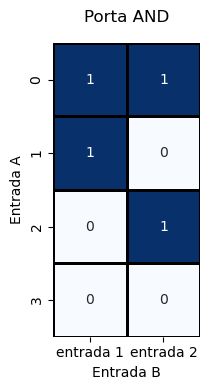

In [12]:
# visualizar graficamente
d = {
    "entrada 1": [entries[0][0], entries[1][0], entries[2][0], entries[3][0]], 
    "entrada 2": [entries[0][1], entries[1][1], entries[2][1], entries[3][1]]
}
df = pd.DataFrame(data=d)
print(df)

# porta AND
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
sns.heatmap(
    df, annot=True, cmap="Blues", cbar=False, ax=axes,
    square=True, linewidths=1, linecolor="black"
)

axes.set_title("Porta AND", fontsize=12, pad=15)
axes.set_xlabel("Entrada B")
axes.set_ylabel("Entrada A")

plt.tight_layout()
plt.show()

## Porta lógica OR

In [4]:
# porta lógica OR
or_function = []
for i in entries:
    print("A entrada foi:", i)
    y_hat = mcculoch_pitts_rna(i, theta=1)
    or_function.append(y_hat)

print("Respectivas saídas:", or_function)

A entrada foi: [1 1]
A entrada foi: [1 0]
A entrada foi: [0 1]
A entrada foi: [0 0]
Respectivas saídas: [1, 1, 1, 0]


## Porta lógica NOT

In [5]:
# porta lógica NOT
not_function = []
for i in entries:
    print("A entrada foi:", i)
    y_hat = mcculoch_pitts_rna(i, theta=1, inhibitory_input=True)
    not_function.append(y_hat)

print("Respectivas saídas:", not_function)

A entrada foi: [1 1]
A entrada foi: [1 0]
A entrada foi: [0 1]
A entrada foi: [0 0]
Respectivas saídas: [0, 1, 0, 0]


B  0  1
A      
0  0  0
1  0  1
B  0  1
A      
0  0  1
1  1  1
B  0  1
A      
0  0  1
1  1  0


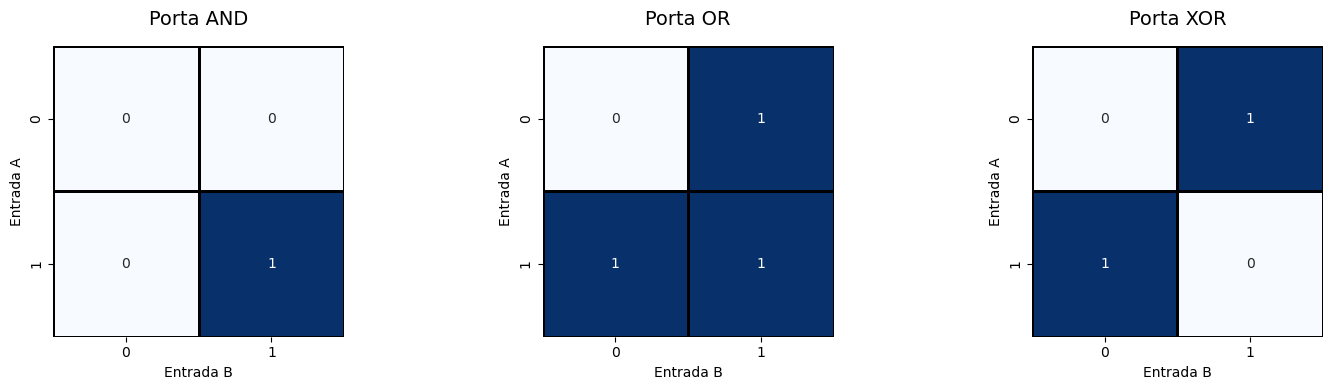

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Criando os dados das portas lógicas
data = {
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1]
}

df = pd.DataFrame(data)

# Calculando os resultados
df['AND'] = df['A'] & df['B']
df['OR'] = df['A'] | df['B']
df['XOR'] = df['A'] ^ df['B']

# 2. Reorganizando os dados para o gráfico (Pivot)
# Vamos criar uma figura com 3 subplots (um para cada porta)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Porta AND', 'Porta OR', 'Porta XOR']
columns = ['AND', 'OR', 'XOR']

for i, col in enumerate(columns):
    # Transformando os dados em uma matriz 2x2 para o heatmap
    pivot_df = df.pivot(index='A', columns='B', values=col)
    print(pivot_df)
    
    sns.heatmap(pivot_df, annot=True, cmap='Blues', cbar=False, ax=axes[i], 
                square=True, linewidths=1, linecolor='black')
    
    axes[i].set_title(titles[i], fontsize=14, pad=15)
    axes[i].set_xlabel('Entrada B')
    axes[i].set_ylabel('Entrada A')

plt.tight_layout()
plt.show()

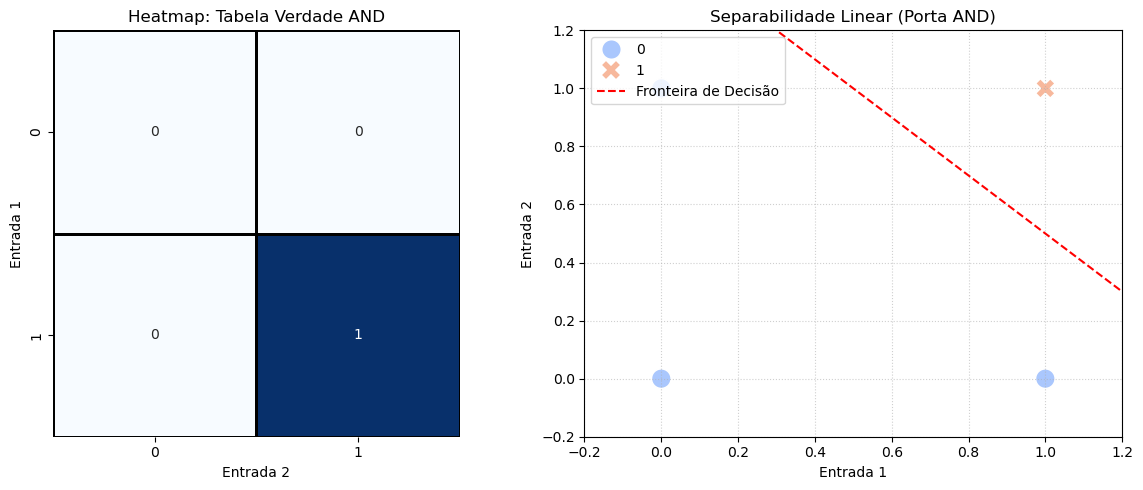

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Dados de entrada
entries = [[0, 0], [0, 1], [1, 0], [1, 1]]
and_function = [0, 0, 0, 1] # Resultado do seu loop anterior

# Criando DataFrame para facilitar a plotagem
df_and = pd.DataFrame({
    'Entrada 1': [i[0] for i in entries],
    'Entrada 2': [i[1] for i in entries],
    'Saída (AND)': and_function
})

# Configurando a figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Heatmap (Tabela Verdade) ---
pivot_df = df_and.pivot(index='Entrada 1', columns='Entrada 2', values='Saída (AND)')
sns.heatmap(pivot_df, annot=True, cmap="Blues", cbar=False, ax=ax1, square=True, linewidths=1, linecolor="black")
ax1.set_title("Heatmap: Tabela Verdade AND")

# --- GRÁFICO 2: Dispersão e Separabilidade Linear ---
sns.scatterplot(data=df_and, x='Entrada 1', y='Entrada 2', hue='Saída (AND)', 
                style='Saída (AND)', s=200, palette='coolwarm', ax=ax2)

# Desenhando a linha de decisão (Linear Separator)
# Para x1 + x2 = 1.5 (um valor entre o ponto [1,1] e os outros)
x_vals = np.array([-0.5, 1.5])
y_vals = 1.5 - x_vals # Relação linear para a fronteira
ax2.plot(x_vals, y_vals, '--', color='red', label='Fronteira de Decisão')

# Ajustes de layout do gráfico de dispersão
ax2.set_title("Separabilidade Linear (Porta AND)")
ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()